<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/Interfacialadsorption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gas–solid adsorption with NeqSim

This tutorial calculates equilibrium adsorption of CO₂, methane, and ethane on porous solids, compares isotherm models, studies pressure and temperature effects, and estimates working capacity and ideal cycle time.

**Learning objectives**

- Build an equilibrium gas feed and identify partial-pressure driving forces.
- Use DRA, Extended Langmuir, Freundlich, Sips, and BET models.
- Explain saturation, competitive adsorption, selectivity, and thermal regeneration.
- Compare adsorbent materials and calculate working capacity.
- Apply numerical and physical validation before engineering use.

In [1]:
import platform
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
            "pandas",
            "matplotlib",
        ]
    )
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neqsim import jneqsim
from neqsim.thermo import TPflash
from neqsim.thermo import fluid

NEQSIM_VERSION = version("neqsim")
PYTHON_VERSION = platform.python_version()
_j = subprocess.run(["java", "-version"], capture_output=True, text=True, check=False)
JAVA_VERSION = ((_j.stderr or _j.stdout).splitlines() or ["unknown"])[0]
print(f"NeqSim {NEQSIM_VERSION} | Python {PYTHON_VERSION} | Java {JAVA_VERSION}")

NeqSim 3.16.0 | Python 3.12.13 | Java openjdk version "17.0.19" 2026-04-21


## 1. Engineering context

Gas–solid adsorption underpins pressure-swing adsorption (PSA), temperature-swing adsorption (TSA), molecular-sieve dehydration, CO₂ removal, contaminant polishing, and gas storage. The equilibrium loading $q_i$ is the amount retained per mass of adsorbent at a specified gas composition, pressure, and temperature.

Equilibrium is only one part of equipment performance. Breakthrough also depends on particle diffusion, film transfer, bed hydrodynamics, heat release, pressure drop, cycle sequencing, and aging.

In [2]:
COMPOSITION = {"CO2": 0.01, "methane": 0.95, "ethane": 0.04}


def make_gas(pressure_bara=10.0, temperature_c=20.0):
    s = fluid("srk")
    for name, z in COMPOSITION.items():
        s.addComponent(name, z)
    s.setMixingRule("classic")
    s.setTemperature(float(temperature_c), "C")
    s.setPressure(float(pressure_bara), "bara")
    TPflash(s)
    s.initPhysicalProperties()
    return s


CLASSES = {
    "Extended Langmuir": jneqsim.physicalproperties.interfaceproperties.solidadsorption.LangmuirAdsorption,
    "Freundlich": jneqsim.physicalproperties.interfaceproperties.solidadsorption.FreundlichAdsorption,
    "Sips": jneqsim.physicalproperties.interfaceproperties.solidadsorption.SipsAdsorption,
    "BET": jneqsim.physicalproperties.interfaceproperties.solidadsorption.BETAdsorption,
    "DRA": jneqsim.physicalproperties.interfaceproperties.solidadsorption.PotentialTheoryAdsorption,
}


def run_model(system, model_name, material="Zeolite 13X"):
    model = CLASSES[model_name](system)
    model.setSolidMaterial(material)
    phase = int(system.getPhaseIndex("gas"))
    if model_name == "Extended Langmuir":
        model.calcExtendedLangmuir(phase)
    elif model_name == "Sips":
        model.calcExtendedSips(phase)
    else:
        model.calcAdsorption(phase)
    return model


def loadings(model):
    return {c: float(model.getSurfaceExcess(c)) for c in COMPOSITION}

## 2. Assumptions and units

- Synthetic dry gas: 1 mol% CO₂, 95 mol% methane, and 4 mol% ethane.
- SRK with the classic mixing rule describes the bulk gas fugacity.
- Loading is reported in mol/kg adsorbent, pressure in bara, and temperature in °C.
- The solid is fresh, isothermal, uniform, and at equilibrium; no water, H₂S, degradation, or mass-transfer resistance is included.
- Database parameters are used for the selected material and components.

No proprietary operating data are used.

In [3]:
base = make_gas()
phase = base.getPhase("gas")
state = pd.DataFrame(
    [
        {
            "temperature [°C]": float(phase.getTemperature("C")),
            "pressure [bara]": float(phase.getPressure("bara")),
            "density [kg/m³]": float(phase.getDensity("kg/m3")),
            **{f"{c} y": float(phase.getComponent(c).getx()) for c in COMPOSITION},
        }
    ]
)
print(state.to_string(index=False, float_format=lambda x: f"{x:.8g}"))

 temperature [°C]  pressure [bara]  density [kg/m³]  CO2 y  methane y  ethane y
               20               10        7.0700071   0.01       0.95      0.04


## 3. Langmuir and competitive adsorption theory

For one component, Langmuir adsorption is

$$q=q_{max}\frac{KP}{1+KP}.$$

For a mixture sharing adsorption sites,

$$q_i=q_{max,i}\frac{K_iP_i}{1+\sum_jK_jP_j}.$$

The common denominator represents competition. Loading is nearly linear at low pressure and approaches a saturation plateau at high pressure.

In [4]:
# The high-level interphase API defaults to the EOS-based DRA model.
legacy = make_gas()
ip = legacy.getInterphaseProperties()
ip.initAdsorption()
ip.setSolidAdsorbentMaterial("Zeolite 13X")
ip.calcAdsorption()
dra_api = ip.getAdsorptionCalc("gas")
dra_api_table = pd.DataFrame(
    {
        "component": list(COMPOSITION),
        "DRA loading [mol/kg]": [float(dra_api.getSurfaceExcess(c)) for c in COMPOSITION],
    }
)
print(dra_api_table.to_string(index=False, float_format=lambda x: f"{x:.6e}"))

component  DRA loading [mol/kg]
      CO2          4.991627e-03
  methane          2.573248e-01
   ethane          1.251978e-02


## 4. API choices

`getInterphaseProperties().initAdsorption()` is retained as a convenient DRA workflow. The current isotherm classes are used directly when an explicit model comparison is needed. `calcExtendedLangmuir` and `calcExtendedSips` account for multicomponent competition; calling only a single-component method would overpredict mixture loading.

The original notebook exposed only one default calculation and mislabeled its output as kg/kg. This revision uses the documented mol/kg basis and names the actual model.

In [5]:
model_rows = []
for name in CLASSES:
    m = run_model(make_gas(), name)
    q = loadings(m)
    model_rows.append(
        {
            "model": name,
            **{f"{c} [mol/kg]": q[c] for c in COMPOSITION},
            "total [mol/kg]": float(m.getTotalSurfaceExcess()),
        }
    )
model_table = pd.DataFrame(model_rows)
print(model_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

            model  CO2 [mol/kg]  methane [mol/kg]  ethane [mol/kg]  total [mol/kg]
Extended Langmuir      1.390257          2.574003         0.203175        4.167435
       Freundlich      1.380640          6.967578         1.559762        9.907980
             Sips      1.561072          2.266831         0.248574        4.076478
              BET      2.198518          6.041029         1.800538       10.040084
              DRA      0.004992          0.257325         0.012520        0.274836


## 5. Isotherm-model comparison

Extended Langmuir provides a bounded competitive monolayer. Sips adds surface heterogeneity while retaining saturation. Freundlich is empirical and does not impose a high-pressure plateau. BET represents multilayer adsorption, while DRA uses an EOS-based micropore-filling calculation. Their numerical spread is model-form uncertainty—not a ranking of universal accuracy.

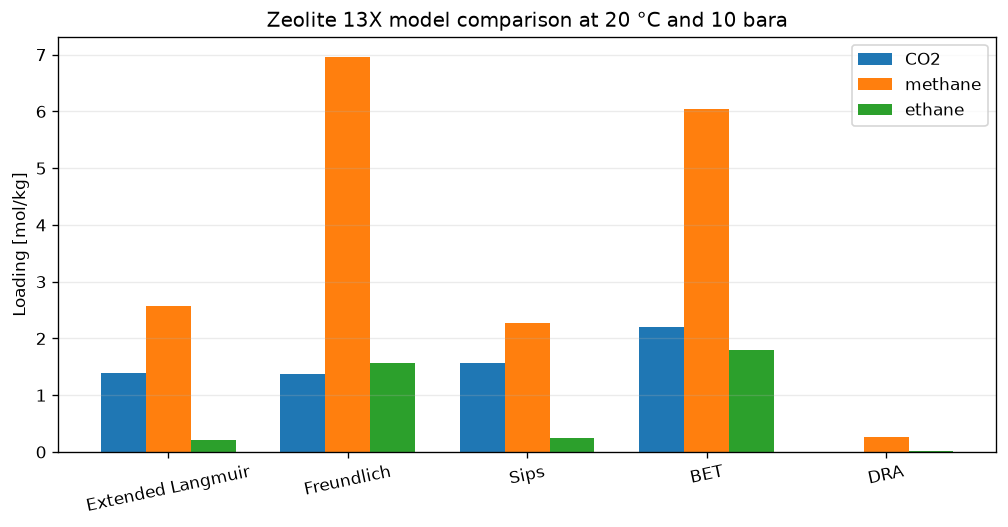

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(model_table))
w = 0.25
for k, c in enumerate(COMPOSITION):
    ax.bar(x + (k - 1) * w, model_table[f"{c} [mol/kg]"], w, label=c)
ax.set_xticks(x, model_table.model, rotation=12)
ax.set_ylabel("Loading [mol/kg]")
ax.set_title("Zeolite 13X model comparison at 20 °C and 10 bara")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## 6. Pressure sensitivity and saturation

Pressure increases all partial pressures and raises loading. The Extended Langmuir denominator makes the incremental gain smaller as sites fill. The high-pressure plateau is a useful physical check and differentiates bounded models from Freundlich behavior.

In [7]:
pressure_rows = []
for P in [1, 2, 5, 10, 20, 40, 80]:
    m = run_model(make_gas(P, 20), "Extended Langmuir")
    q = loadings(m)
    pressure_rows.append({"pressure [bara]": P, **{f"{c} [mol/kg]": q[c] for c in COMPOSITION}})
pressure_table = pd.DataFrame(pressure_rows)
print(pressure_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

 pressure [bara]  CO2 [mol/kg]  methane [mol/kg]  ethane [mol/kg]
               1      0.416386          0.770921         0.060852
               2      0.681667          1.262078         0.099620
               5      1.103489          2.043064         0.161266
              10      1.390257          2.574003         0.203175
              20      1.597881          2.958410         0.233518
              40      1.726825          3.197145         0.252362
              80      1.799429          3.331568         0.262972


## 7. Pressure-study interpretation

All loadings should rise monotonically, but the slope should decrease. CO₂ can show high adsorption selectivity even at only 1 mol% in the feed because adsorption affinity—not gas concentration alone—controls equilibrium uptake.

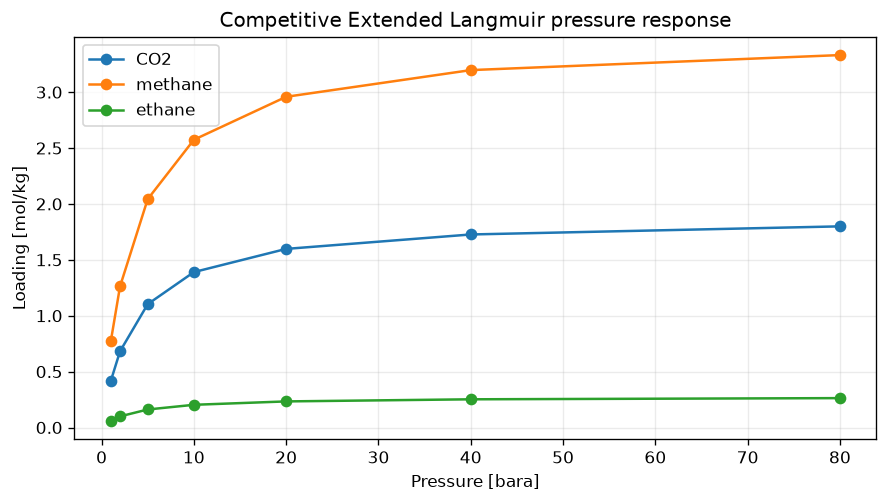

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
for c in COMPOSITION:
    ax.plot(pressure_table["pressure [bara]"], pressure_table[f"{c} [mol/kg]"], "o-", label=c)
ax.set(
    xlabel="Pressure [bara]",
    ylabel="Loading [mol/kg]",
    title="Competitive Extended Langmuir pressure response",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 8. Temperature dependence and TSA

Physical adsorption is normally exothermic. Its affinity follows a van ’t Hoff form, so raising temperature reduces loading:

$$K(T)=K(T_{ref})\exp\left[-\frac{\Delta H_{ads}}{R}\left(\frac1T-\frac1{T_{ref}}\right)\right].$$

This provides the thermodynamic basis for temperature-swing regeneration.

In [9]:
temperature_rows = []
for T in [0, 20, 40, 60, 80, 100]:
    m = run_model(make_gas(10, T), "Extended Langmuir")
    q = loadings(m)
    temperature_rows.append({"temperature [°C]": T, **{f"{c} [mol/kg]": q[c] for c in COMPOSITION}})
temperature_table = pd.DataFrame(temperature_rows)
print(temperature_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

 temperature [°C]  CO2 [mol/kg]  methane [mol/kg]  ethane [mol/kg]
                0      2.289008          2.505244         0.219671
               20      1.390257          2.574003         0.203175
               40      0.808290          2.367170         0.170475
               60      0.462889          2.029439         0.134822
               80      0.266818          1.673025         0.103469
              100      0.156980          1.354764         0.078600


## 9. Temperature-study interpretation

CO₂ loading falls strongly with temperature, while competitive interactions can make individual hydrocarbon trends less uniform over a limited interval. The validation therefore requires the total loading and CO₂ loading to decrease rather than imposing an unsupported universal trend on every component.

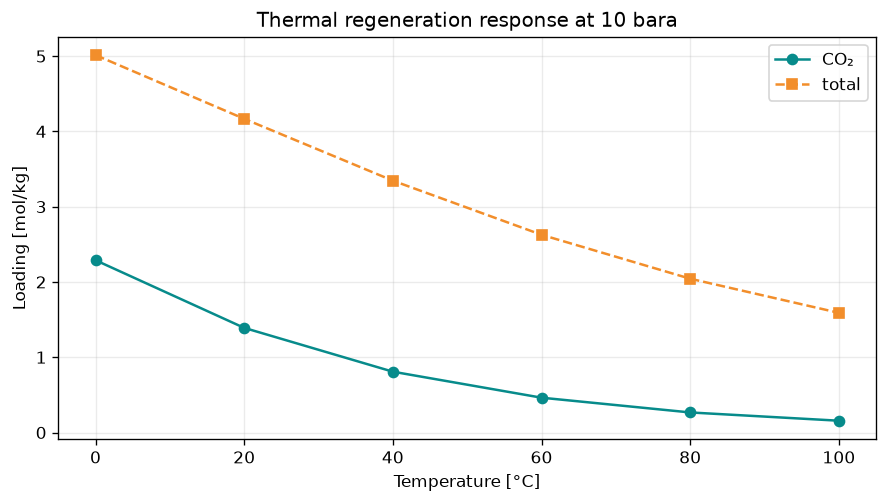

In [10]:
temperature_table["total [mol/kg]"] = temperature_table[[f"{c} [mol/kg]" for c in COMPOSITION]].sum(
    axis=1
)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.plot(
    temperature_table["temperature [°C]"],
    temperature_table["CO2 [mol/kg]"],
    "o-",
    label="CO₂",
    color="#078b8b",
)
ax.plot(
    temperature_table["temperature [°C]"],
    temperature_table["total [mol/kg]"],
    "s--",
    label="total",
    color="#f28e2b",
)
ax.set(
    xlabel="Temperature [°C]",
    ylabel="Loading [mol/kg]",
    title="Thermal regeneration response at 10 bara",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 10. Adsorbent-material screening

NeqSim’s adsorption parameter database includes activated carbons, zeolites, molecular sieves, silica gel, MOFs, and other materials. A short comparison demonstrates how the same gas and isotherm can be screened across candidates. It does not replace vendor equilibrium and kinetic data.

In [11]:
materials = ["AC", "AC Norit R1", "Zeolite 13X", "Zeolite 5A", "CMS"]
material_rows = []
for material in materials:
    m = run_model(make_gas(), "Extended Langmuir", material)
    q = loadings(m)
    material_rows.append({"material": material, **{f"{c} [mol/kg]": q[c] for c in COMPOSITION}})
material_table = pd.DataFrame(material_rows)
print(material_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

   material  CO2 [mol/kg]  methane [mol/kg]  ethane [mol/kg]
         AC      0.301234          5.515408         0.313857
AC Norit R1      0.338015          7.681861         0.040864
Zeolite 13X      1.390257          2.574003         0.203175
 Zeolite 5A      1.166437          1.963390         0.183790
        CMS      0.177699          1.295895         0.116847


## 11. Competitive selectivity

An equilibrium selectivity can be screened as

$$\alpha_{CO_2/CH_4}=\frac{q_{CO_2}/y_{CO_2}}{q_{CH_4}/y_{CH_4}}.$$

A value above one means the solid enriches CO₂ relative to methane. Selectivity must be interpreted together with absolute working capacity and kinetics.

   material  CO₂/CH₄ equilibrium selectivity
         AC                            5.189
AC Norit R1                            4.180
Zeolite 13X                           51.311
 Zeolite 5A                           56.439
        CMS                           13.027


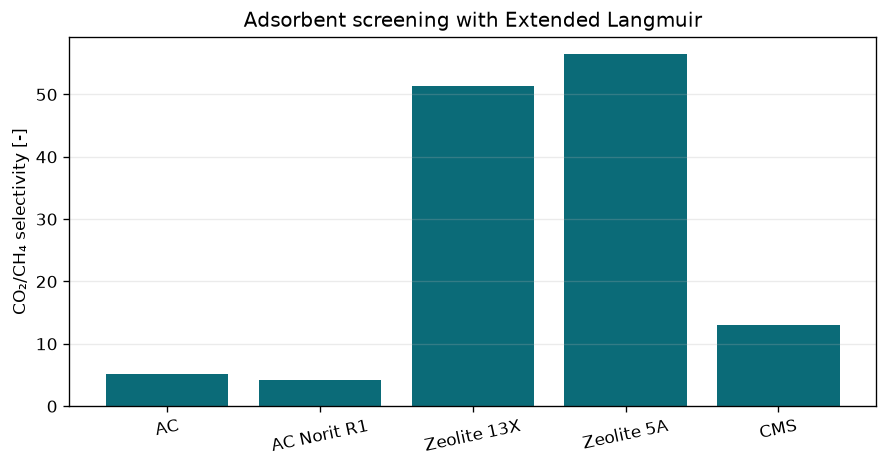

In [12]:
selectivity_rows = []
for _, r in material_table.iterrows():
    alpha = (r["CO2 [mol/kg]"] / COMPOSITION["CO2"]) / (
        r["methane [mol/kg]"] / COMPOSITION["methane"]
    )
    selectivity_rows.append({"material": r.material, "CO₂/CH₄ equilibrium selectivity": alpha})
selectivity_table = pd.DataFrame(selectivity_rows)
print(selectivity_table.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(selectivity_table.material, selectivity_table.iloc[:, 1], color="#0b6b78")
ax.set_ylabel("CO₂/CH₄ selectivity [-]")
ax.set_title("Adsorbent screening with Extended Langmuir")
ax.tick_params(axis="x", rotation=12)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## 12. Working capacity and ideal cycle estimate

PSA working capacity is the loading difference between adsorption and regeneration states:

$$\Delta q_i=q_i(P_{ads},T_{ads})-q_i(P_{regen},T_{regen}).$$

For an adsorbent mass $m_s$, the ideal captured mass is $m_s\Delta q_iM_i$. Dividing by inlet contaminant molar flow gives a theoretical cycle time before saturation; real cycles are shorter because beds are not in uniform equilibrium.

In [13]:
m_ads = run_model(make_gas(10, 20), "Extended Langmuir")
m_reg = run_model(make_gas(1, 20), "Extended Langmuir")
q_ads = loadings(m_ads)
q_reg = loadings(m_reg)
adsorbent_mass_kg = 1000.0
co2_feed_kmol_h = 1.0
WORKING_CO2 = q_ads["CO2"] - q_reg["CO2"]
captured_co2_kg = WORKING_CO2 * adsorbent_mass_kg * 0.04401
IDEAL_CYCLE_H = WORKING_CO2 * adsorbent_mass_kg / (co2_feed_kmol_h * 1000)
working_table = pd.DataFrame(
    [
        {
            "CO₂ adsorption loading [mol/kg]": q_ads["CO2"],
            "CO₂ regeneration loading [mol/kg]": q_reg["CO2"],
            "working capacity [mol/kg]": WORKING_CO2,
            "CO₂ per cycle [kg]": captured_co2_kg,
            "ideal cycle time [h]": IDEAL_CYCLE_H,
        }
    ]
)
print(working_table.to_string(index=False, float_format=lambda x: f"{x:.5f}"))

 CO₂ adsorption loading [mol/kg]  CO₂ regeneration loading [mol/kg]  working capacity [mol/kg]  CO₂ per cycle [kg]  ideal cycle time [h]
                         1.39026                            0.41639                    0.97387            42.86007               0.97387


## 13. Validation, applicability, and limitations

The final assertions verify phase identity, finite non-negative loadings, model totals, pressure saturation behavior, thermal regeneration, material selectivity, and working-capacity closure. Limitations include equilibrium-only behavior, ideal solid condition, parameter uncertainty, no co-adsorbed water, no heat balance, and no breakthrough model. Vendor data and cyclic pilot tests remain essential for design guarantees.

In [14]:
load_cols = [f"{c} [mol/kg]" for c in COMPOSITION]
checks = {
    "single gas phase": int(base.getNumberOfPhases()) == 1 and base.hasPhaseType("gas"),
    "gas composition closes": abs(sum(float(phase.getComponent(c).getx()) for c in COMPOSITION) - 1)
    < 1e-12,
    "gas density physically plausible": 1 < float(phase.getDensity("kg/m3")) < 100,
    "DRA API values finite nonnegative": np.isfinite(dra_api_table.iloc[:, 1]).all()
    and (dra_api_table.iloc[:, 1] >= 0).all(),
    "all model values finite nonnegative": np.isfinite(model_table[load_cols + ["total [mol/kg]"]])
    .all()
    .all()
    and (model_table[load_cols + ["total [mol/kg]"]] >= 0).all().all(),
    "model component sums close": np.allclose(
        model_table[load_cols].sum(axis=1), model_table["total [mol/kg]"], rtol=1e-10
    ),
    "pressure loadings increase": all((np.diff(pressure_table[c]) > 0).all() for c in load_cols),
    "pressure increments diminish": np.diff(pressure_table["CO2 [mol/kg]"])[-1]
    < np.diff(pressure_table["CO2 [mol/kg]"])[0],
    "CO2 loading decreases with temperature": (
        np.diff(temperature_table["CO2 [mol/kg]"]) < 0
    ).all(),
    "total loading decreases overall": temperature_table["total [mol/kg]"].iloc[-1]
    < temperature_table["total [mol/kg]"].iloc[0],
    "material values finite positive": np.isfinite(material_table[load_cols]).all().all()
    and (material_table[load_cols] > 0).all().all(),
    "selectivities finite positive": np.isfinite(selectivity_table.iloc[:, 1]).all()
    and (selectivity_table.iloc[:, 1] > 0).all(),
    "working capacity positive": WORKING_CO2 > 0 and captured_co2_kg > 0 and IDEAL_CYCLE_H > 0,
    "working-capacity mass closes": abs(captured_co2_kg - WORKING_CO2 * adsorbent_mass_kg * 0.04401)
    < 1e-12,
}
failed = [k for k, v in checks.items() if not bool(v)]
assert not failed, "Validation failures: " + ", ".join(failed)
print(pd.DataFrame({"check": checks.keys(), "passed": checks.values()}).to_string(index=False))
print(f"\nAll {len(checks)} engineering checks passed with NeqSim {NEQSIM_VERSION}.")

                                 check  passed
                      single gas phase    True
                gas composition closes    True
      gas density physically plausible    True
     DRA API values finite nonnegative    True
   all model values finite nonnegative    True
            model component sums close    True
            pressure loadings increase    True
          pressure increments diminish    True
CO2 loading decreases with temperature    True
       total loading decreases overall    True
       material values finite positive    True
         selectivities finite positive    True
             working capacity positive    True
          working-capacity mass closes    True

All 14 engineering checks passed with NeqSim 3.16.0.


## 14. Documentation and exercises

- [Adsorption isotherm models and parameter database](https://equinor.github.io/neqsim/thermo/adsorption_isotherms.html)
- [Interfacial properties and adsorption workflow](https://equinor.github.io/neqsim/physical_properties/interfacial_properties.html)
- [NeqSim physical-properties overview](https://equinor.github.io/neqsim/physical_properties/README.html)

**Exercises:** add water and assess competitive dehydration; compare PSA and TSA working capacities; fit Langmuir parameters to public isotherm data; add a mass-transfer-zone model; couple adsorber outlet gas to a downstream NeqSim process.

In [15]:
summary = pd.DataFrame(
    {
        "metric": [
            "Zeolite 13X CO₂ loading at adsorption",
            "Zeolite 13X CO₂ working capacity",
            "CO₂ captured per ideal cycle",
            "Ideal equilibrium cycle time",
        ],
        "value": [q_ads["CO2"], WORKING_CO2, captured_co2_kg, IDEAL_CYCLE_H],
        "unit": ["mol/kg", "mol/kg", "kg", "h"],
    }
)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
print(f"Runtime: NeqSim {NEQSIM_VERSION}; Python {PYTHON_VERSION}; {JAVA_VERSION}")

                               metric    value   unit
Zeolite 13X CO₂ loading at adsorption  1.39026 mol/kg
     Zeolite 13X CO₂ working capacity  0.97387 mol/kg
         CO₂ captured per ideal cycle 42.86007     kg
         Ideal equilibrium cycle time  0.97387      h
Runtime: NeqSim 3.16.0; Python 3.12.13; openjdk version "17.0.19" 2026-04-21


## 15. Practical next step

Use this equilibrium notebook as the thermodynamic layer beneath a cyclic adsorber model. The next engineering step is to add axial mass and energy balances, particle kinetics, pressure drop, valve sequencing, and breakthrough validation. Keep the equilibrium model and its parameter provenance visible so process performance can be traced back to measured isotherms.

In [16]:
print(
    "Notebook completed with equilibrium tables, four deterministic plots, working-capacity calculations, and passing assertions."
)

Notebook completed with equilibrium tables, four deterministic plots, working-capacity calculations, and passing assertions.
